# 12: Permutation-Based Methods: GRaSP and BOSS

Permutation-based causal discovery searches over variable orderings. Once an order is proposed, each variable can only choose parents that appear earlier in that order. This turns the graph search problem into an order-search problem: find a good ordering, then infer a sparse DAG consistent with that ordering.

We introduce two `causal-learn` permutation-based methods:

- **BOSS**: Best Order Score Search.
- **GRaSP**: Greedy Relaxation of the Sparsest Permutation.

Both methods use local scores and order mutations to search for a graph. They are useful bridges between exact score search and scalable greedy graph search: more structured than arbitrary edge edits, but much cheaper than enumerating all DAGs.

Expected runtime: usually under 1 minute on this example dataset. The stability loops run multiple random starts, but each run is small and fast.

## Learning Goals

By the end, you should be able to:

- Explain why variable orderings are useful search objects for DAG discovery.
- Understand how a fixed order restricts possible parent sets.
- Run `BOSS` and `GRaSP` from `causal-learn`.
- Compare permutation-based output with GES and exact search on a small graph.
- Check random-start stability for order-based methods.
- Study how GRaSP depth and sample size affect graph recovery.
- Report permutation-based results without overstating what the search guarantees.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Permutation-Based Methods: GRaSP And BOSS**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some notebooks omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment studies order-based search. The quality of an ordering is interpreted through recovered parent sets and stability.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

Score-based discovery searches over graphs by balancing model fit and complexity. A common score has the form

$$
\operatorname{BIC}(G)=-2\ell(\widehat\theta_G;X)+\lambda\operatorname{dim}(G)\log(n).
$$

Greedy methods move through graph space locally. Exact methods optimize more globally but become expensive as the number of variables grows. A high-scoring graph is an estimated model under a score, not automatic causal truth.



We start with order-search theory, then set up the environment and load the same linear Gaussian example dataset used by the GES and exact-search notebooks. After that we show what a fixed order implies, run BOSS and GRaSP, compare them with GES and exact search, and stress-test stability across seeds, GRaSP depths, and sample sizes.

The notebook uses the linear Gaussian dataset because the permutation methods here use BIC-style local scores. That keeps the score assumptions aligned with the data-generating mechanism.




## Tutorial Workflow

### Permutation-Based Discovery Theory

A DAG always has at least one topological order: an ordering of variables where every parent appears before its children. If we know the correct order, the graph search becomes much easier. For each variable, we only need to decide which earlier variables are its parents.

For example, suppose the order is:

```text
need, intent, match, engagement, renewal, support
```

Then `match` may choose parents from `need` and `intent`, but it cannot choose `renewal` as a parent because `renewal` appears later. The order itself forbids backward edges.

Permutation-based algorithms exploit this fact. They search over orders and use local scores to decide which parents are useful within each order.

### From Orders to Parent Sets

For a fixed order, the best parent set for each node can be scored locally. With a decomposable score, the total graph score is:

$$
S(G) = \sum_i S_i(\mathrm{Pa}(X_i))
$$

The local score for `X_i` only depends on the parent set of `X_i`. Under an order, the candidate parent set must be a subset of variables that appear before `X_i`.

This is the key computational move. Instead of exploring arbitrary directed graphs, the algorithm asks: “if this order were true, which earlier variables would each node choose as parents?” Then it mutates the order to see if a better score is possible.

#### Sparsest Permutation Intuition

The sparsest permutation idea says that the right causal order should allow a sparse graph that explains the conditional dependence structure. If the order is wrong, the algorithm may need extra edges or awkward orientations to explain the same data.

This does not mean the sparsest graph is always the true graph. Finite samples, weak effects, hidden variables, and score mismatch can all distort sparsity. But the idea is powerful: a good order should make parent selection simple.

GRaSP searches for better permutations by relaxing and mutating orders. BOSS searches by moving variables through an order when doing so improves the score.

### BOSS versus GRaSP

BOSS and GRaSP are both order-based, but they move through order space differently.

**BOSS** repeatedly considers moving variables to better positions in the order. After an order is updated, parent sets are recomputed from local scores. It is a greedy best-order search.

**GRaSP** starts with an order and uses covered-edge style relaxations, called tucks in the implementation, to improve the sparsest permutation. The `depth` argument controls how deep the relaxation search can go. Larger depth can escape some shallow local traps, but it can also cost more time.

Both methods can depend on random starts or random traversal choices. That is why stability across seeds is part of this lesson.

### Relationship to GES and Exact Search

GES greedily edits an equivalence-class graph by adding and removing edges. Exact search optimizes the score globally over a small allowed space. BOSS and GRaSP take a third route: they search over permutations and derive parent sets consistent with those permutations.

All three families can use decomposable scores, so they can agree on friendly small problems. They can also disagree because their search paths and constraints differ.

For a small example graph, exact search is a useful benchmark. For larger graphs, permutation methods may be more practical than exact search while still giving a structured search over possible causal orderings.

### What Permutation Methods Can and Cannot Claim

Permutation methods can find high-scoring DAGs and useful causal orders under score assumptions. They are especially helpful when order structure is easier to search than arbitrary graph structure.

Score optimization alone is evidence under a model. It still depends on observed variables, score choice, sample size, model class, and absence of major hidden confounding.

A careful report should include the score function, penalty, random seeds or restarts, depth settings for GRaSP, runtime, stability, and comparison to other methods.

#### Setup

The code below imports the scientific Python stack, BOSS, GRaSP, GES, exact BIC search, and plotting utilities. It also applies a compatibility wrapper for the BIC score used by recent NumPy versions. The wrapper preserves the same scoring formula while safely converting one-element matrix results into Python scalars.

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import contextlib
import io
import itertools
import os
import random
import time
import warnings

# Resolve paths before importing matplotlib so the cache directory stays writable.
CWD = Path.cwd()
if CWD.name == "causal_learn" and (CWD / "outputs").exists():
    NOTEBOOK_DIR = CWD
else:
    NOTEBOOK_DIR = (CWD / "notebooks" / "tutorials" / "causal_learn").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in [OUTPUT_DIR, DATASET_DIR, TABLE_DIR, FIGURE_DIR, REPORT_DIR, OUTPUT_DIR / "matplotlib_cache"]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / "matplotlib_cache"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Using 'local_score_BIC_from_cov' instead for efficiency")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

import causallearn.search.PermutationBased.BOSS as boss_module
import causallearn.search.PermutationBased.GRaSP as grasp_module
import causallearn.search.ScoreBased.GES as ges_module
from causallearn.search.PermutationBased.BOSS import boss
from causallearn.search.PermutationBased.GRaSP import grasp
from causallearn.search.ScoreBased.GES import ges
from causallearn.search.ScoreBased.ExactSearch import bic_exact_search

NOTEBOOK_PREFIX = "12"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.facecolor"] = "white"


def local_score_BIC_from_cov(Data, i, PAi, parameters=None):
    """
    Compatibility wrapper for causal-learn BIC-from-cov scoring under recent NumPy scalar behavior.
    
    Parameters
    ----------
    Data : array-like
        Data matrix passed by causal-learn into the local score function.
    i : int
        Target variable index for the local score calculation.
    PAi : list[int]
        Parent indices proposed for the target variable in the local score.
    parameters : dict
        Score-function parameters supplied by causal-learn.
    
    Returns
    -------
    float
        BIC-style local score for one target variable and candidate parent set.
    """
    cov, n = Data
    lambda_value = 0.5 if parameters is None else parameters.get("lambda_value", 0.5)
    sigma = float(cov[i, i])
    if len(PAi) > 0:
        yX = cov[np.ix_([i], PAi)]
        XX = cov[np.ix_(PAi, PAi)]
        try:
            XX_inv = np.linalg.inv(XX)
        except np.linalg.LinAlgError:
            XX_inv = np.linalg.pinv(XX)
        sigma = float(cov[i, i] - (yX @ XX_inv @ yX.T).item())
    sigma = max(sigma, 1e-12)
    return -0.5 * n * (1 + np.log(sigma)) - lambda_value * (len(PAi) + 1) * np.log(n)

# Patch the modules that build LocalScoreClass objects during this lesson session.
boss_module.local_score_BIC_from_cov = local_score_BIC_from_cov
grasp_module.local_score_BIC_from_cov = local_score_BIC_from_cov
ges_module.local_score_BIC_from_cov = local_score_BIC_from_cov

packages = ["causal-learn", "numpy", "pandas", "matplotlib", "seaborn"]
version_rows = []
for package in packages:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package, "version": package_version})

package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)


,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2


The setup confirms the environment and patches the local score function before any permutation method is run. BOSS, GRaSP, and GES will all use the same safe BIC wrapper in this lesson.

#### Load the Linear Gaussian Example Data

We use the linear Gaussian dataset from the synthetic data tutorial because it matches the BIC score assumptions well. The known true graph lets us measure recovery rather than judging graphs by appearance alone.

In [2]:
# Save the artifacts produced by the Load The Linear Gaussian Example Data section.
linear_path = DATASET_DIR / "02_linear_gaussian.csv"
truth_path = TABLE_DIR / "02_base_true_dag_edges.csv"

linear_df = pd.read_csv(linear_path)
true_edges = pd.read_csv(truth_path)
VARIABLES = list(linear_df.columns)

loaded_summary = pd.DataFrame(
    [
        {
            "artifact": "linear Gaussian data",
            "path": str(linear_path.relative_to(NOTEBOOK_DIR)),
            "rows": len(linear_df),
            "columns": linear_df.shape[1],
        },
        {
            "artifact": "true edge table",
            "path": str(truth_path.relative_to(NOTEBOOK_DIR)),
            "rows": len(true_edges),
            "columns": true_edges.shape[1],
        },
    ]
)
loaded_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_loaded_dataset_summary.csv", index=False)

display(loaded_summary)
display(linear_df.head())
display(true_edges)


,artifact,path,rows,columns
0,linear Gaussian data,outputs/datasets/02_linear_gaussian.csv,2500,6
1,true edge table,outputs/tables/02_base_true_dag_edges.csv,6,4


,need,intent,match,engagement,renewal,support
0,0.249820,-0.372094,0.060245,0.667197,0.252766,-0.280058
1,0.683671,-0.210471,0.904969,1.004727,0.320095,-0.332215
2,-0.579752,-1.202671,-0.578579,-0.235444,-0.732431,0.594102
3,-0.902823,-0.077309,-0.771219,-0.531128,-0.105721,-1.503551
4,-1.985745,0.087297,-0.691315,-1.281731,-0.797906,-0.328219


,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support contact.


The data has six observed variables. That is small enough to compare BOSS, GRaSP, GES, and exact search directly without turning the notebook into a runtime exercise.

#### Helper Functions

These helpers convert causal-learn graph objects into tidy edge tables, compute recovery metrics, score fixed orders, and draw graphs in the same visual style used throughout the tutorial.

In [3]:
# Define reusable helpers for the Helper Functions section.
def parse_causallearn_edge(edge):
    """
    Convert a causal-learn edge object into source, endpoint pattern, and target strings.
    
    Parameters
    ----------
    edge : object
        Graph edge object or edge row being parsed, classified, or drawn.
    
    Returns
    -------
    tuple[str, str, str]
        Source node, endpoint mark, and target node parsed from a causal-learn edge.
    """
    parts = str(edge).strip().split()
    if len(parts) != 3:
        return {"source": str(edge), "edge_type": "unknown", "target": "unknown"}
    return {"source": parts[0], "edge_type": parts[1], "target": parts[2]}


def graph_to_edge_table(graph, label):
    """
    Return a tidy edge table from a causal-learn graph object.
    
    Parameters
    ----------
    graph : object
        Graph object returned by causal-learn or constructed from the edge table.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Edge table with source, target, edge mark, and method metadata.
    """
    rows = [parse_causallearn_edge(edge) for edge in graph.get_graph_edges()]
    edge_df = pd.DataFrame(rows, columns=["source", "edge_type", "target"])
    if edge_df.empty:
        edge_df = pd.DataFrame(columns=["source", "edge_type", "target"])
    edge_df.insert(0, "run", label)
    return edge_df


def adjacency_to_edge_table(adjacency, variables, label):
    """
    Convert a parent-row, child-column adjacency matrix into a tidy directed edge table.
    
    Parameters
    ----------
    adjacency : object
        Adjacency matrix encoding candidate parent-child edges.
    variables : list[str]
        Variables included in the graph, lag frame, or diagnostic.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Graph edge table for adjacency to edge table, including node names and edge-orientation information where available.
    """
    rows = []
    for parent_idx, child_idx in zip(*np.where(adjacency > 0)):
        rows.append(
            {
                "run": label,
                "source": variables[int(parent_idx)],
                "edge_type": "-->",
                "target": variables[int(child_idx)],
            }
        )
    return pd.DataFrame(rows, columns=["run", "source", "edge_type", "target"])


def directed_pairs(edge_df):
    """
    Extract definite directed pairs from an edge table.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    
    Returns
    -------
    set[tuple[str, str]]
        Ordered source-target pairs representing directed learned edges.
    """
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.edge_type == "-->":
            pairs.add((row.source, row.target))
        elif row.edge_type == "<--":
            pairs.add((row.target, row.source))
    return pairs


def skeleton_pairs(edge_df):
    """
    Extract adjacencies while ignoring direction.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    
    Returns
    -------
    set[tuple[str, str]]
        Unordered node pairs representing the learned graph skeleton.
    """
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.target != "unknown":
            pairs.add(frozenset([row.source, row.target]))
    return pairs


def summarize_against_truth(edge_df, truth_df, label):
    """
    Compute graph-recovery metrics against a directed truth table.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    truth_df : pd.DataFrame
        Oracle edge table used as the synthetic ground-truth benchmark.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Graph-recovery summary table with edge counts, precision, recall, missing edges, and extra edges.
    """
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    learned_directed = directed_pairs(edge_df)
    learned_skeleton = skeleton_pairs(edge_df)

    correct_directed = learned_directed & true_directed
    reversed_true = {(src, dst) for src, dst in true_directed if (dst, src) in learned_directed}
    missing_skeleton = true_skeleton - learned_skeleton
    extra_skeleton = learned_skeleton - true_skeleton

    unresolved_true = 0
    for src, dst in true_directed:
        pair = frozenset([src, dst])
        if pair in learned_skeleton and (src, dst) not in learned_directed and (dst, src) not in learned_directed:
            unresolved_true += 1

    directed_count = len(learned_directed)
    return pd.DataFrame(
        [
            {
                "run": label,
                "learned_edges_total": len(edge_df),
                "definite_directed_edges": directed_count,
                "true_edges": len(true_directed),
                "correct_directed_edges": len(correct_directed),
                "directed_precision": len(correct_directed) / directed_count if directed_count else np.nan,
                "directed_recall": len(correct_directed) / len(true_directed) if true_directed else np.nan,
                "reversed_true_edges": len(reversed_true),
                "unresolved_true_adjacencies": unresolved_true,
                "missing_true_adjacencies": len(missing_skeleton),
                "extra_adjacencies": len(extra_skeleton),
            }
        ]
    )


def run_boss(data_df, label, seed=1, lambda_value=0.5):
    """
    Run BOSS with a controlled random seed.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    label : str
        Readable label attached to the method, scenario, or output row.
    seed : int
        Random seed for reproducible simulation or resampling.
    lambda_value : float
        Numeric value for `lambda`.
    
    Returns
    -------
    tuple
        Tuple containing graph, edge_table, elapsed.
    """
    random.seed(seed)
    np.random.seed(seed)
    start = time.perf_counter()
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        graph = boss(
            data_df.to_numpy(),
            score_func="local_score_BIC_from_cov",
            parameters={"lambda_value": lambda_value},
            verbose=False,
            node_names=list(data_df.columns),
        )
    elapsed = time.perf_counter() - start
    edge_table = graph_to_edge_table(graph, label=label)
    return graph, edge_table, elapsed


def run_grasp(data_df, label, seed=1, depth=4, lambda_value=0.5):
    """
    Run GRaSP with a controlled random seed and chosen depth.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    label : str
        Readable label attached to the method, scenario, or output row.
    seed : int
        Random seed for reproducible simulation or resampling.
    depth : int
        Maximum conditioning-set depth used by the discovery algorithm.
    lambda_value : float
        Numeric value for `lambda`.
    
    Returns
    -------
    tuple
        Tuple containing graph, edge_table, elapsed.
    """
    random.seed(seed)
    np.random.seed(seed)
    start = time.perf_counter()
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        graph = grasp(
            data_df.to_numpy(),
            score_func="local_score_BIC_from_cov",
            depth=depth,
            parameters={"lambda_value": lambda_value},
            verbose=False,
            node_names=list(data_df.columns),
        )
    elapsed = time.perf_counter() - start
    edge_table = graph_to_edge_table(graph, label=label)
    return graph, edge_table, elapsed


def run_ges_bic(data_df, label, lambda_value=0.5):
    """
    Run BIC-GES quietly for comparison.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    label : str
        Readable label attached to the method, scenario, or output row.
    lambda_value : float
        Numeric value for `lambda`.
    
    Returns
    -------
    tuple
        Tuple containing record, edge_table, elapsed.
    """
    start = time.perf_counter()
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        record = ges(
            data_df.to_numpy(),
            score_func="local_score_BIC",
            node_names=list(data_df.columns),
            lambda_value=lambda_value,
        )
    elapsed = time.perf_counter() - start
    edge_table = graph_to_edge_table(record["G"], label=label)
    return record, edge_table, elapsed


def run_exact_bic(data_df, label):
    """
    Run exact BIC search with A* for the small example graph.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    tuple
        Tuple containing adjacency, stats, edge_table, elapsed.
    """
    start = time.perf_counter()
    adjacency, stats = bic_exact_search(data_df.to_numpy(), search_method="astar", verbose=False)
    elapsed = time.perf_counter() - start
    edge_table = adjacency_to_edge_table(adjacency, list(data_df.columns), label=label)
    return adjacency, stats, edge_table, elapsed


def best_parent_sets_for_order(data_df, order, lambda_value=0.5, max_parents=None):
    """
    Exhaustively choose the best parent set for each node given a fixed order.
    
    Parameters
    ----------
    data_df : pd.DataFrame
        Dataset for the current simulated or observed experiment.
    order : object
        Variable ordering proposed by an order-based graph-search method.
    lambda_value : float
        Numeric value for `lambda`.
    max_parents : object
        Maximum number of candidate parents allowed in the graph search.
    
    Returns
    -------
    tuple
        Tuple containing parent_table, edge_table, total_score.
    """
    data = data_df.to_numpy()
    cov = np.cov(data.T, ddof=0)
    n = data.shape[0]
    index = {name: i for i, name in enumerate(data_df.columns)}
    rows = []
    edge_rows = []
    total_score = 0.0

    for position, child in enumerate(order):
        child_idx = index[child]
        candidate_parents = list(order[:position])
        parent_limit = len(candidate_parents) if max_parents is None else min(max_parents, len(candidate_parents))
        best_score = -np.inf
        best_parents = []
        for size in range(parent_limit + 1):
            for parent_names in itertools.combinations(candidate_parents, size):
                parent_indices = [index[name] for name in parent_names]
                score = local_score_BIC_from_cov((cov, n), child_idx, parent_indices, {"lambda_value": lambda_value})
                if score > best_score:
                    best_score = score
                    best_parents = list(parent_names)
        total_score += best_score
        rows.append(
            {
                "order_label": " -> ".join(order),
                "child": child,
                "position": position + 1,
                "allowed_parent_count": len(candidate_parents),
                "selected_parents": ", ".join(best_parents) if best_parents else "none",
                "local_score": best_score,
            }
        )
        for parent in best_parents:
            edge_rows.append({"run": "fixed_order", "source": parent, "edge_type": "-->", "target": child})

    parent_table = pd.DataFrame(rows)
    edge_table = pd.DataFrame(edge_rows, columns=["run", "source", "edge_type", "target"])
    return parent_table, edge_table, total_score


GRAPH_POSITIONS = {
    "need": (0.11, 0.72),
    "intent": (0.11, 0.28),
    "match": (0.39, 0.50),
    "engagement": (0.62, 0.50),
    "renewal": (0.89, 0.72),
    "support": (0.89, 0.28),
}
NODE_LABELS = {name: name.title() for name in GRAPH_POSITIONS}
NODE_COLORS = {
    "need": "#e0f2fe",
    "intent": "#dbeafe",
    "match": "#ecfccb",
    "engagement": "#fef3c7",
    "renewal": "#fee2e2",
    "support": "#f3e8ff",
}


def trim_edge_to_box(start, end, box_w=0.145, box_h=0.095, gap=0.012):
    """
    Return edge endpoints that stop just outside source and target boxes.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    end : tuple[float, float]
        Ending coordinate of the arrow or edge segment.
    box_w : float
        Width of the node box used to trim edge endpoints.
    box_h : float
        Height of the node box used to trim edge endpoints.
    gap : float
        Extra spacing between an edge endpoint and a node boundary.
    
    Returns
    -------
    tuple[tuple[float, float], tuple[float, float]]
        Start and end coordinates trimmed so the edge stops at box boundaries.
    """
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))
    if length == 0:
        return start, end
    effective_w = box_w + 0.04
    effective_h = box_h + 0.04
    x_limit = (effective_w / 2) / abs(dx) if dx else np.inf
    y_limit = (effective_h / 2) / abs(dy) if dy else np.inf
    t = min(x_limit, y_limit) + gap / length
    return (x0 + dx * t, y0 + dy * t), (x1 - dx * t, y1 - dy * t)


def draw_box_graph(edge_df, title, path, note=None):
    """
    Draw a DAG-style graph with rounded boxes and visible arrowheads.
    
    Parameters
    ----------
    edge_df : pd.DataFrame
        Learned or oracle edge table being summarized or drawn.
    title : str
        Title shown above the plot or saved artifact.
    path : str or pathlib.Path
        Output path where the figure or artifact is saved.
    note : str or None
        Optional explanatory note shown in the plot.
    
    Returns
    -------
    None
        Draws the graph diagram directly on the Matplotlib axes and saves it when requested.
    """
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_axis_off()
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0.04, 0.96)
    box_w, box_h = 0.145, 0.095

    for row in edge_df.itertuples(index=False):
        if row.source not in GRAPH_POSITIONS or row.target not in GRAPH_POSITIONS:
            continue
        raw_start = GRAPH_POSITIONS[row.source]
        raw_end = GRAPH_POSITIONS[row.target]
        if row.edge_type == "<--":
            raw_start, raw_end = raw_end, raw_start
        start, end = trim_edge_to_box(raw_start, raw_end, box_w=box_w, box_h=box_h)
        if row.edge_type in {"-->", "<--"}:
            arrowstyle = "-|>"
            mutation_scale = 18
            linewidth = 1.8
            color = "#334155"
        else:
            arrowstyle = "-"
            mutation_scale = 1
            linewidth = 1.5
            color = "#64748b"
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=mutation_scale,
            linewidth=linewidth,
            color=color,
            connectionstyle="arc3,rad=0.035",
            zorder=2,
        )
        ax.add_patch(arrow)

    for node, (x, y) in GRAPH_POSITIONS.items():
        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.018",
            facecolor=NODE_COLORS[node],
            edgecolor="#1f2937",
            linewidth=1.1,
            zorder=5,
        )
        ax.add_patch(rect)
        ax.text(x, y, NODE_LABELS[node], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=6)

    if note:
        ax.text(0.50, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=18, fontsize=14, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def truth_as_edge_table(truth_df, label="truth"):
    """
    Convert a truth table into a plotting-ready edge table.
    
    Parameters
    ----------
    truth_df : pd.DataFrame
        Oracle edge table used as the synthetic ground-truth benchmark.
    label : str
        Readable label attached to the method, scenario, or output row.
    
    Returns
    -------
    pd.DataFrame
        Oracle graph edge table with run label and directed-edge marks.
    """
    return truth_df.assign(run=label, edge_type="-->")[["run", "source", "edge_type", "target"]]


The helper set includes a small fixed-order scorer. That scorer is not a replacement for BOSS or GRaSP; it is a teaching device for seeing how a proposed order restricts parent choices.

#### Draw the True DAG

Before running order-based methods, we draw the known data-generating DAG. This is the target used in the recovery metrics.

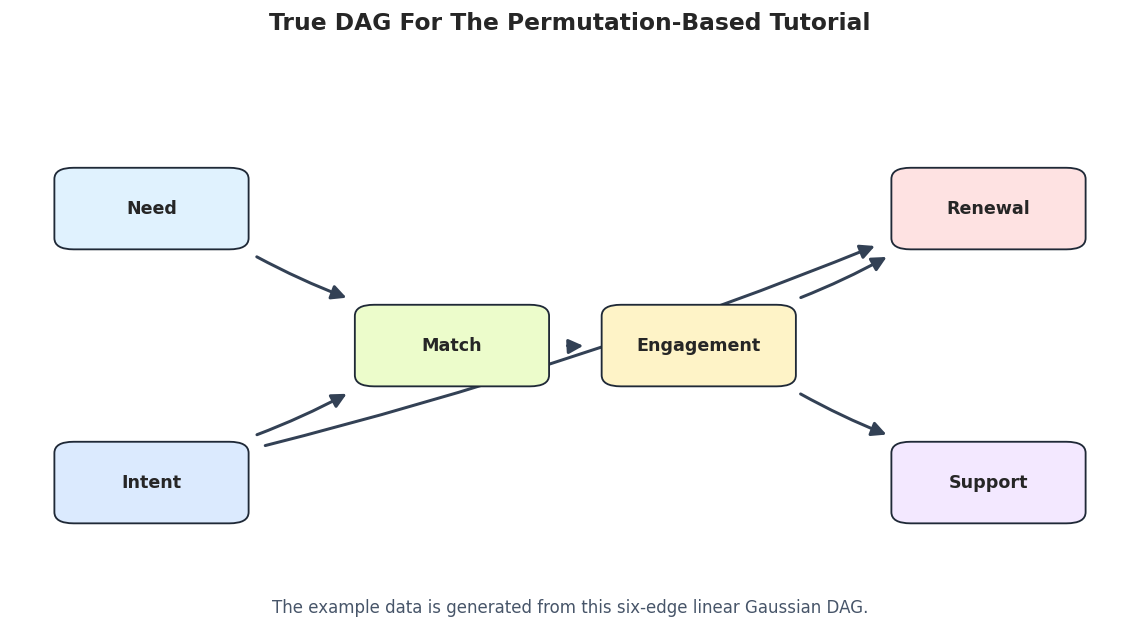

In [4]:
true_plot_edges = truth_as_edge_table(true_edges)
draw_box_graph(
    true_plot_edges,
    title="True DAG For The Permutation-Based Tutorial",
    path=FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_dag.png",
    note="The example data is generated from this six-edge linear Gaussian DAG.",
)

The true graph has two root variables, a mediator chain, and two downstream outcomes. A good order should place causes before effects so parent selection can recover these edges.

#### Fixed-Order Parent Selection Demo

The code below shows why order matters. We compare a plausible causal order with a deliberately reversed order. For each order, the code finds the best local BIC parent set for every node using only variables that appear earlier in the order.

In [5]:
# Save the artifacts produced by the Fixed-Order Parent Selection Demo section.
causal_order = ["need", "intent", "match", "engagement", "renewal", "support"]
reversed_order = list(reversed(causal_order))

fixed_order_rows = []
fixed_order_edge_tables = []
for order_name, order in [("causal_order", causal_order), ("reversed_order", reversed_order)]:
    parent_table, edge_table, total_score = best_parent_sets_for_order(
        linear_df,
        order,
        lambda_value=0.5,
        max_parents=3,
    )
    parent_table["order_name"] = order_name
    parent_table["total_order_score"] = total_score
    edge_table["run"] = order_name
    fixed_order_rows.append(parent_table)
    fixed_order_edge_tables.append(edge_table)

fixed_order_parent_sets = pd.concat(fixed_order_rows, ignore_index=True)
fixed_order_edges = pd.concat(fixed_order_edge_tables, ignore_index=True)
fixed_order_metrics = pd.concat(
    [
        summarize_against_truth(fixed_order_edges[fixed_order_edges["run"] == name], true_edges, name)
        for name in ["causal_order", "reversed_order"]
    ],
    ignore_index=True,
)
order_score_summary = fixed_order_parent_sets.groupby("order_name", as_index=False).agg(
    total_order_score=("total_order_score", "first"),
    selected_parent_links=("selected_parents", lambda values: sum(value != "none" for value in values)),
)

fixed_order_parent_sets.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fixed_order_parent_sets.csv", index=False)
fixed_order_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fixed_order_edges.csv", index=False)
fixed_order_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fixed_order_metrics.csv", index=False)
order_score_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fixed_order_score_summary.csv", index=False)

display(order_score_summary.round(4))
display(fixed_order_parent_sets[["order_name", "child", "position", "selected_parents", "local_score"]].round(4))
display(fixed_order_metrics.round(4))


,order_name,total_order_score,selected_parent_links
0,causal_order,-2547.9957,4
1,reversed_order,-2562.6663,5


,order_name,child,position,selected_parents,local_score
0,causal_order,need,1,none,-1253.9120
1,causal_order,intent,2,none,-1253.9120
2,causal_order,match,3,"need, intent",504.3279
3,causal_order,engagement,4,match,142.9078
4,causal_order,renewal,5,"intent, engagement",53.2493
5,causal_order,support,6,engagement,-740.6566
6,reversed_order,support,1,none,-1253.9120
7,reversed_order,renewal,2,support,-1058.9669
8,reversed_order,engagement,3,"support, renewal",-197.2864
9,reversed_order,match,4,"renewal, engagement",234.5766


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies
0,causal_order,6,6,6,6,1.0,1.0,0,0,0,0
1,reversed_order,10,10,6,0,0.0,0.0,6,0,0,4


The causal order should score better and recover the direct structure more naturally. The reversed order may still fit dependencies, but it must explain them with backward or awkward parent choices.

#### Run BOSS and GRaSP

Now we run the actual permutation-based algorithms. The baseline uses the same BIC penalty as the GES comparison later and fixes the random seed so the notebook is reproducible.

In [6]:
# Save the artifacts produced by the Run BOSS And GRaSP section.
BASELINE_SEED = 1
LAMBDA_VALUE = 0.5
GRASP_DEPTH = 4

boss_graph, boss_edges, boss_elapsed = run_boss(
    linear_df,
    label="BOSS",
    seed=BASELINE_SEED,
    lambda_value=LAMBDA_VALUE,
)
grasp_graph, grasp_edges, grasp_elapsed = run_grasp(
    linear_df,
    label="GRaSP_depth_4",
    seed=BASELINE_SEED,
    depth=GRASP_DEPTH,
    lambda_value=LAMBDA_VALUE,
)

permutation_edges = pd.concat([boss_edges, grasp_edges], ignore_index=True)
permutation_metrics = pd.concat(
    [
        summarize_against_truth(boss_edges, true_edges, "BOSS"),
        summarize_against_truth(grasp_edges, true_edges, "GRaSP_depth_4"),
    ],
    ignore_index=True,
)
permutation_metrics["elapsed_seconds"] = [boss_elapsed, grasp_elapsed]
permutation_metrics["seed"] = BASELINE_SEED
permutation_metrics["lambda_value"] = LAMBDA_VALUE

permutation_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_boss_grasp_edges.csv", index=False)
permutation_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_boss_grasp_metrics.csv", index=False)

display(permutation_edges)
display(permutation_metrics.round(4))


,run,source,edge_type,target
0,BOSS,need,-->,match
1,BOSS,intent,-->,match
2,BOSS,intent,-->,renewal
3,BOSS,match,-->,engagement
4,BOSS,engagement,-->,renewal
5,BOSS,engagement,-->,support
6,GRaSP_depth_4,need,-->,match
7,GRaSP_depth_4,intent,-->,match
8,GRaSP_depth_4,intent,-->,renewal
9,GRaSP_depth_4,match,-->,engagement


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,elapsed_seconds,seed,lambda_value
0,BOSS,6,6,6,6,1.0,1.0,0,0,0,0,0.0123,1,0.5
1,GRaSP_depth_4,6,6,6,6,1.0,1.0,0,0,0,0,0.0100,1,0.5


On this friendly six-variable dataset, both methods should recover the same core graph. That is reassuring, but the stability sections below are still necessary because order-search algorithms can depend on random starts and search settings.

#### Draw the BOSS Graph

The BOSS graph is drawn first because BOSS is a clean baseline for best-order score search in this lesson.

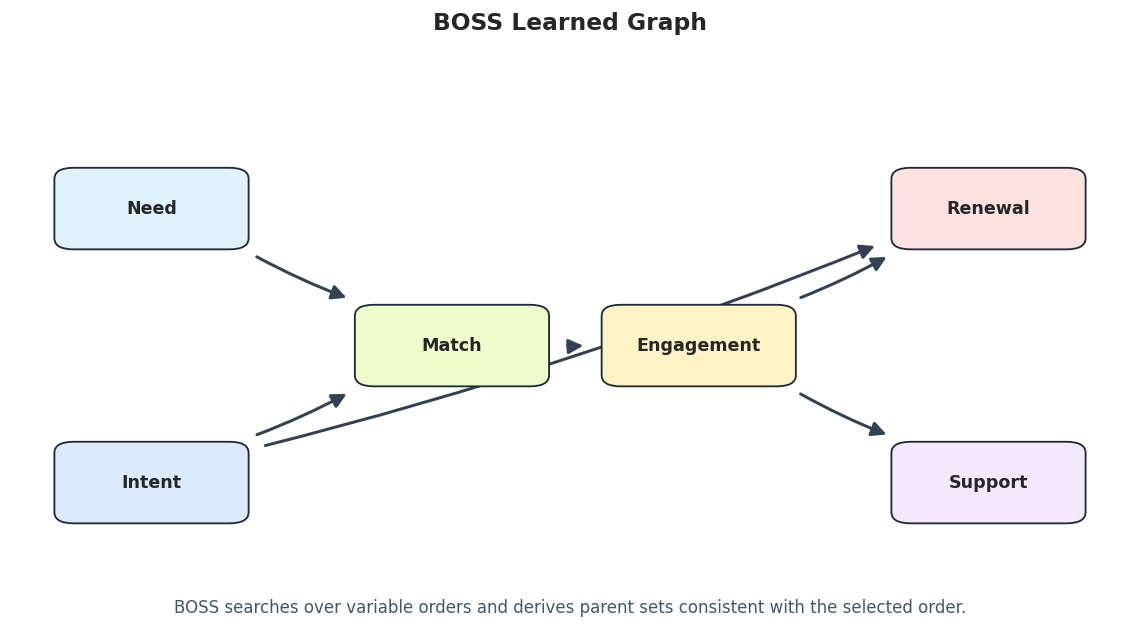

In [7]:
draw_box_graph(
    boss_edges,
    title="BOSS Learned Graph",
    path=FIGURE_DIR / f"{NOTEBOOK_PREFIX}_boss_graph.png",
    note="BOSS searches over variable orders and derives parent sets consistent with the selected order.",
)

The graph layout matches the true DAG layout so differences are easy to see. For this baseline seed and dataset, the learned graph should be visually aligned with the true structure.




## Diagnostics and Interpretation

### Compare with GES and Exact Search

Permutation-based search is one way to optimize graph structure. To anchor the result, we compare BOSS and GRaSP with GES and exact BIC search on the same data.

In [8]:
ges_record, ges_edges, ges_elapsed = run_ges_bic(linear_df, label="GES_BIC", lambda_value=LAMBDA_VALUE)
exact_adjacency, exact_stats, exact_edges, exact_elapsed = run_exact_bic(linear_df, label="Exact_BIC_AStar")

method_edges = pd.concat([boss_edges, grasp_edges, ges_edges, exact_edges], ignore_index=True)
method_metrics = pd.concat(
    [
        summarize_against_truth(boss_edges, true_edges, "BOSS"),
        summarize_against_truth(grasp_edges, true_edges, "GRaSP_depth_4"),
        summarize_against_truth(ges_edges, true_edges, "GES_BIC"),
        summarize_against_truth(exact_edges, true_edges, "Exact_BIC_AStar"),
    ],
    ignore_index=True,
)
method_metrics["elapsed_seconds"] = [boss_elapsed, grasp_elapsed, ges_elapsed, exact_elapsed]
method_metrics["search_family"] = ["permutation", "permutation", "score_greedy", "score_exact"]

method_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_method_comparison_edges.csv", index=False)
method_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_method_comparison_metrics.csv", index=False)
pd.DataFrame([exact_stats]).to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_exact_search_stats.csv", index=False)

display(method_edges)
display(method_metrics.round(4))


,run,source,edge_type,target
0,BOSS,need,-->,match
1,BOSS,intent,-->,match
2,BOSS,intent,-->,renewal
3,BOSS,match,-->,engagement
4,BOSS,engagement,-->,renewal
5,BOSS,engagement,-->,support
6,GRaSP_depth_4,need,-->,match
7,GRaSP_depth_4,intent,-->,match
8,GRaSP_depth_4,intent,-->,renewal
9,GRaSP_depth_4,match,-->,engagement


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,elapsed_seconds,search_family
0,BOSS,6,6,6,6,1.0,1.0,0,0,0,0,0.0123,permutation
1,GRaSP_depth_4,6,6,6,6,1.0,1.0,0,0,0,0,0.0100,permutation
2,GES_BIC,6,6,6,6,1.0,1.0,0,0,0,0,0.0227,score_greedy
3,Exact_BIC_AStar,6,6,6,6,1.0,1.0,0,0,0,0,0.0156,score_exact


Agreement across BOSS, GRaSP, GES, and exact search is a strong teaching result for this small aligned dataset. In real data, disagreement is often more informative than agreement because it exposes assumption and search sensitivity.

#### Plot Method Comparison

The table above is compact, but a plot makes recovery differences easier to scan. We focus on directed correctness, unresolved true adjacencies, and extra adjacencies.

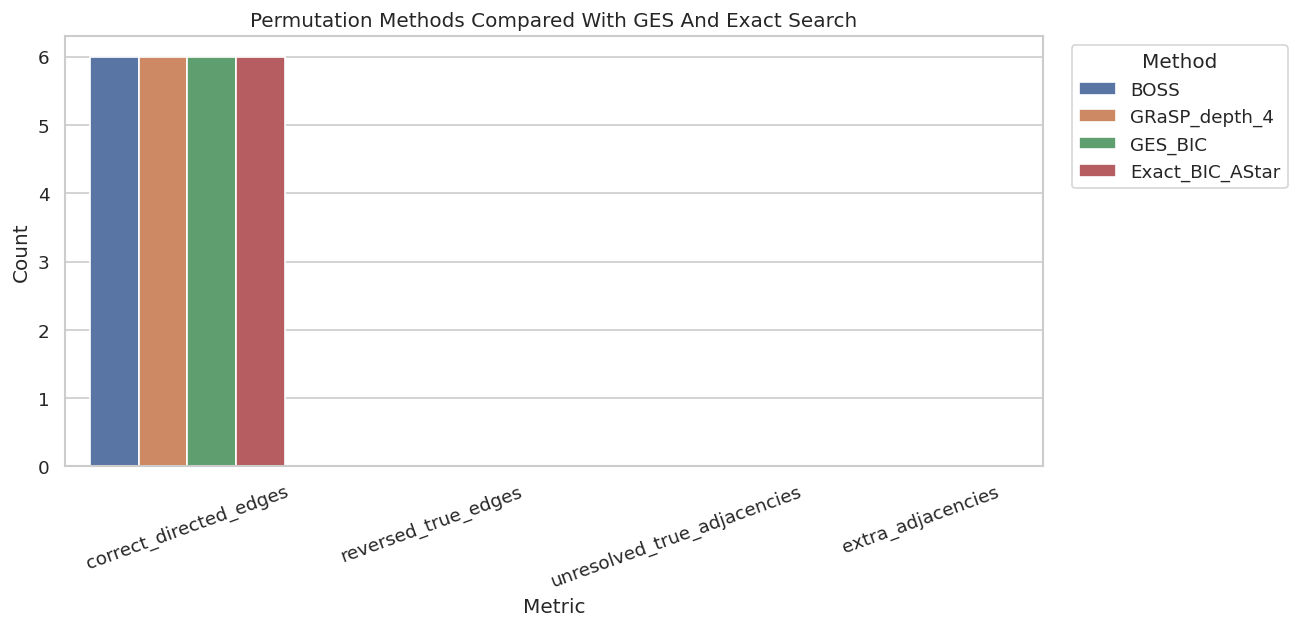

In [9]:
method_plot_df = method_metrics.melt(
    id_vars=["run", "search_family"],
    value_vars=["correct_directed_edges", "reversed_true_edges", "unresolved_true_adjacencies", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)

fig, ax = plt.subplots(figsize=(11, 5.4))
sns.barplot(data=method_plot_df, x="metric", y="count", hue="run", ax=ax)
ax.set_title("Permutation Methods Compared With GES And Exact Search")
ax.set_xlabel("Metric")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_method_comparison_metrics.png", dpi=160, bbox_inches="tight")
plt.show()


The plot should show that all methods perform well in this controlled setting. The later sensitivity sections are where differences become more visible.

That makes the comparison interpretable: differences across methods can be tied to estimator behavior instead of hidden changes in preprocessing or evaluation.
<!-- result-implication-expanded -->


### Random-Seed Stability

BOSS and GRaSP use random order traversal or random starting choices. The code below repeats each method across several seeds and records whether the recovered graph changes.

In [10]:
# Save the artifacts produced by the Random-Seed Stability section.
stability_rows = []
stability_edges = []
for seed in range(10):
    for method_name in ["BOSS", "GRaSP_depth_4"]:
        if method_name == "BOSS":
            _, edge_table, elapsed = run_boss(linear_df, label=f"BOSS_seed_{seed}", seed=seed, lambda_value=LAMBDA_VALUE)
        else:
            _, edge_table, elapsed = run_grasp(linear_df, label=f"GRaSP_seed_{seed}", seed=seed, depth=GRASP_DEPTH, lambda_value=LAMBDA_VALUE)
        metrics = summarize_against_truth(edge_table, true_edges, label=f"{method_name}_seed_{seed}")
        metrics["method"] = method_name
        metrics["seed"] = seed
        metrics["elapsed_seconds"] = elapsed
        edge_signature = " | ".join(sorted(f"{row.source} {row.edge_type} {row.target}" for row in edge_table.itertuples(index=False)))
        metrics["edge_signature"] = edge_signature
        stability_rows.append(metrics)
        edge_table["method"] = method_name
        edge_table["seed"] = seed
        stability_edges.append(edge_table)

seed_stability_metrics = pd.concat(stability_rows, ignore_index=True)
seed_stability_edges = pd.concat(stability_edges, ignore_index=True)
seed_stability_summary = seed_stability_metrics.groupby("method", as_index=False).agg(
    runs=("seed", "count"),
    unique_graphs=("edge_signature", "nunique"),
    mean_correct_directed_edges=("correct_directed_edges", "mean"),
    min_correct_directed_edges=("correct_directed_edges", "min"),
    max_extra_adjacencies=("extra_adjacencies", "max"),
    median_elapsed_seconds=("elapsed_seconds", "median"),
)

seed_stability_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_seed_stability_metrics.csv", index=False)
seed_stability_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_seed_stability_edges.csv", index=False)
seed_stability_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_seed_stability_summary.csv", index=False)

display(seed_stability_summary.round(4))
display(seed_stability_metrics[["method", "seed", "correct_directed_edges", "unresolved_true_adjacencies", "extra_adjacencies", "elapsed_seconds"]].round(4))


,method,runs,unique_graphs,mean_correct_directed_edges,min_correct_directed_edges,max_extra_adjacencies,median_elapsed_seconds
0,BOSS,10,1,6.0,6,0,0.0090
1,GRaSP_depth_4,10,1,6.0,6,0,0.0078


,method,seed,correct_directed_edges,unresolved_true_adjacencies,extra_adjacencies,elapsed_seconds
0,BOSS,0,6,0,0,0.0099
1,GRaSP_depth_4,0,6,0,0,0.0086
2,BOSS,1,6,0,0,0.0091
3,GRaSP_depth_4,1,6,0,0,0.0074
4,BOSS,2,6,0,0,0.0088
5,GRaSP_depth_4,2,6,0,0,0.0080
6,BOSS,3,6,0,0,0.0092
7,GRaSP_depth_4,3,6,0,0,0.0060
8,BOSS,4,6,0,0,0.0088
9,GRaSP_depth_4,4,6,0,0,0.0102


The stability summary is the practical safeguard. If a method returns several distinct graphs across seeds, the report should mention that sensitivity rather than presenting one seed as definitive.

#### Plot Seed Stability

This plot shows recovery variation across random seeds. For a stable method and an easy dataset, the points should cluster tightly.

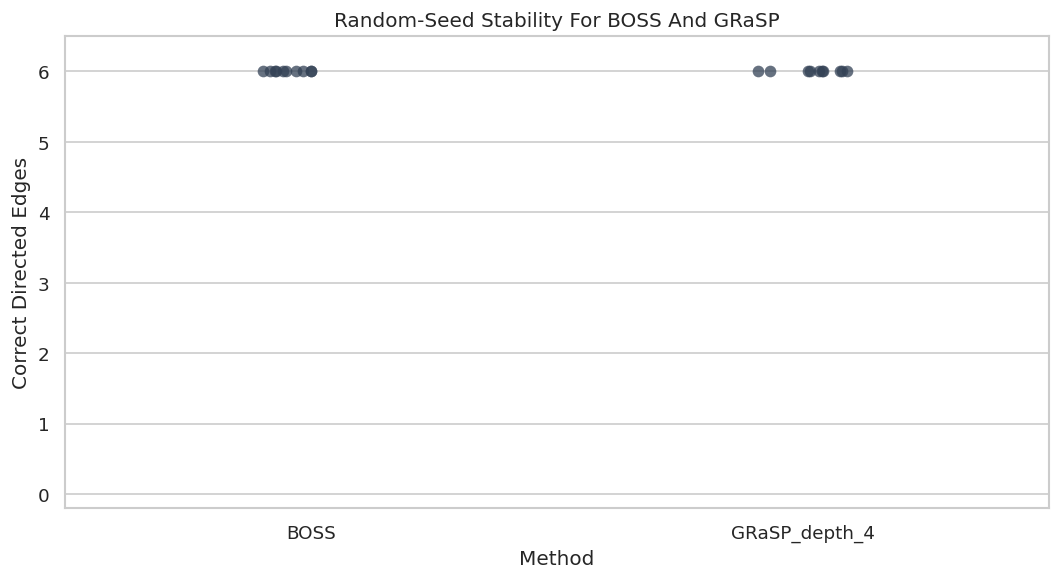

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.stripplot(
    data=seed_stability_metrics,
    x="method",
    y="correct_directed_edges",
    color="#334155",
    size=7,
    alpha=0.75,
    ax=ax,
)
ax.set_title("Random-Seed Stability For BOSS And GRaSP")
ax.set_xlabel("Method")
ax.set_ylabel("Correct Directed Edges")
ax.set_ylim(-0.2, len(true_edges) + 0.5)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_seed_stability.png", dpi=160, bbox_inches="tight")
plt.show()


Seed sensitivity serves a different role than automatically bad. It changes how results should be communicated. Stable relationships across many starts are more credible than relationships that appear in one lucky order.

### GRaSP Depth Sensitivity

GRaSP has a `depth` parameter controlling how deeply it searches relaxation moves. Larger depth can help escape shallow local structures, but it can also increase runtime. The code below compares several depths across a few seeds.

In [12]:
# Save the artifacts produced by the GRaSP Depth Sensitivity section.
depth_rows = []
for depth in [1, 2, 3, 4]:
    for seed in range(5):
        _, edge_table, elapsed = run_grasp(
            linear_df,
            label=f"GRaSP_depth_{depth}_seed_{seed}",
            seed=seed,
            depth=depth,
            lambda_value=LAMBDA_VALUE,
        )
        metrics = summarize_against_truth(edge_table, true_edges, label=f"GRaSP_depth_{depth}_seed_{seed}")
        metrics["depth"] = depth
        metrics["seed"] = seed
        metrics["elapsed_seconds"] = elapsed
        depth_rows.append(metrics)

grasp_depth_metrics = pd.concat(depth_rows, ignore_index=True)
grasp_depth_summary = grasp_depth_metrics.groupby("depth", as_index=False).agg(
    runs=("seed", "count"),
    mean_correct_directed_edges=("correct_directed_edges", "mean"),
    min_correct_directed_edges=("correct_directed_edges", "min"),
    mean_extra_adjacencies=("extra_adjacencies", "mean"),
    median_elapsed_seconds=("elapsed_seconds", "median"),
)

grasp_depth_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_grasp_depth_metrics.csv", index=False)
grasp_depth_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_grasp_depth_summary.csv", index=False)

display(grasp_depth_summary.round(4))
display(grasp_depth_metrics[["depth", "seed", "correct_directed_edges", "unresolved_true_adjacencies", "extra_adjacencies", "elapsed_seconds"]].round(4))


,depth,runs,mean_correct_directed_edges,min_correct_directed_edges,mean_extra_adjacencies,median_elapsed_seconds
0,1,5,4.4,2,0.4,0.0083
1,2,5,3.6,2,0.6,0.0079
2,3,5,4.4,2,0.4,0.0082
3,4,5,6.0,6,0.0,0.0080


,depth,seed,correct_directed_edges,unresolved_true_adjacencies,extra_adjacencies,elapsed_seconds
0,1,0,2,4,1,0.0109
1,1,1,6,0,0,0.0075
2,1,2,6,0,0,0.0090
3,1,3,6,0,0,0.0076
4,1,4,2,4,1,0.0083
5,2,0,2,4,1,0.0089
6,2,1,2,4,1,0.0067
7,2,2,6,0,0,0.0079
8,2,3,6,0,0,0.0061
9,2,4,2,4,1,0.0081


Depth sensitivity shows that a search setting can change the result even when the score and data are fixed. That is exactly why algorithm settings belong in the report.

#### Plot GRaSP Depth Sensitivity

This plot summarizes how correct directed recovery changes with depth across seeds.

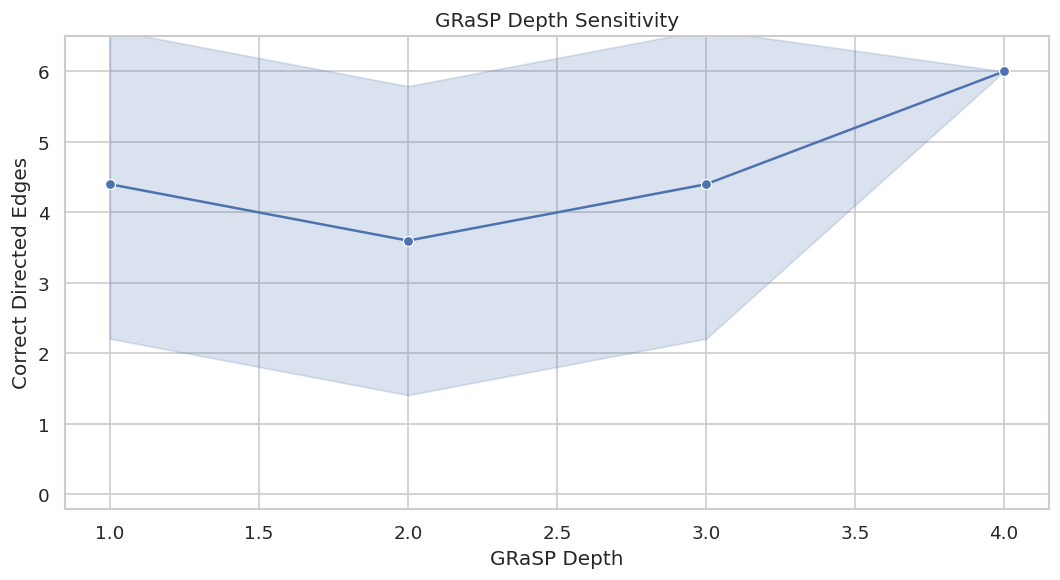

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=grasp_depth_metrics,
    x="depth",
    y="correct_directed_edges",
    marker="o",
    errorbar="sd",
    ax=ax,
)
ax.set_title("GRaSP Depth Sensitivity")
ax.set_xlabel("GRaSP Depth")
ax.set_ylabel("Correct Directed Edges")
ax.set_ylim(-0.2, len(true_edges) + 0.5)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_grasp_depth_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()


For this dataset, deeper search should generally be more stable. On larger datasets, depth can trade off accuracy and runtime, so it is worth tuning deliberately rather than leaving it unexplained.

#### Sample-Size Sensitivity

Order-based methods still rely on local scores estimated from data. With fewer rows, local scores are noisier, and the preferred order or parent sets can change. The code below runs BOSS and GRaSP on increasing sample sizes.

In [14]:
sample_rows = []
for sample_size in [100, 200, 400, len(linear_df)]:
    sample_df = linear_df.sample(n=sample_size, replace=False, random_state=sample_size).reset_index(drop=True)
    for method_name in ["BOSS", "GRaSP_depth_4"]:
        if method_name == "BOSS":
            _, edge_table, elapsed = run_boss(sample_df, label=f"BOSS_n_{sample_size}", seed=BASELINE_SEED, lambda_value=LAMBDA_VALUE)
        else:
            _, edge_table, elapsed = run_grasp(sample_df, label=f"GRaSP_n_{sample_size}", seed=BASELINE_SEED, depth=GRASP_DEPTH, lambda_value=LAMBDA_VALUE)
        metrics = summarize_against_truth(edge_table, true_edges, label=f"{method_name}_n_{sample_size}")
        metrics["method"] = method_name
        metrics["sample_size"] = sample_size
        metrics["elapsed_seconds"] = elapsed
        sample_rows.append(metrics)

sample_size_metrics = pd.concat(sample_rows, ignore_index=True)
sample_size_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_metrics.csv", index=False)
display(sample_size_metrics.round(4))


,run,learned_edges_total,definite_directed_edges,true_edges,correct_directed_edges,directed_precision,directed_recall,reversed_true_edges,unresolved_true_adjacencies,missing_true_adjacencies,extra_adjacencies,method,sample_size,elapsed_seconds
0,BOSS_n_100,8,6,6,5,0.8333,0.8333,1,0,0,2,BOSS,100,0.0116
1,GRaSP_depth_4_n_100,9,6,6,1,0.1667,0.1667,2,3,0,3,GRaSP_depth_4,100,0.0057
2,BOSS_n_200,6,6,6,6,1.0000,1.0000,0,0,0,0,BOSS,200,0.0086
3,GRaSP_depth_4_n_200,6,6,6,6,1.0000,1.0000,0,0,0,0,GRaSP_depth_4,200,0.0083
4,BOSS_n_400,6,6,6,6,1.0000,1.0000,0,0,0,0,BOSS,400,0.0093
5,GRaSP_depth_4_n_400,7,4,6,1,0.2500,0.1667,2,3,0,1,GRaSP_depth_4,400,0.0108
6,BOSS_n_2500,6,6,6,6,1.0000,1.0000,0,0,0,0,BOSS,2500,0.0091
7,GRaSP_depth_4_n_2500,6,6,6,6,1.0000,1.0000,0,0,0,0,GRaSP_depth_4,2500,0.0072


Sample-size sensitivity is about evidence quality, more than runtime. A graph that appears only at one sample size deserves more caution than a graph that stabilizes as the sample grows.

#### Plot Sample-Size Sensitivity

This plot tracks correct directed recovery as the number of rows increases.

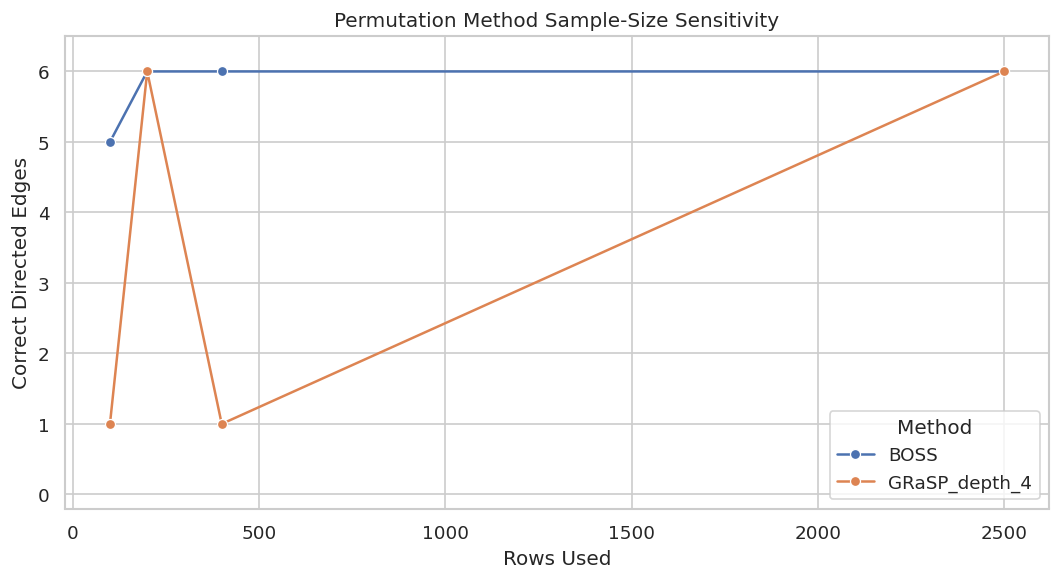

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=sample_size_metrics, x="sample_size", y="correct_directed_edges", hue="method", marker="o", ax=ax)
ax.set_title("Permutation Method Sample-Size Sensitivity")
ax.set_xlabel("Rows Used")
ax.set_ylabel("Correct Directed Edges")
ax.set_ylim(-0.2, len(true_edges) + 0.5)
ax.legend(title="Method")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_sample_size_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The plot should be read as a stability diagnostic. It shows whether the method becomes more reliable as score estimates get more data.



#### Runtime and Scaling Sketch

Permutation methods scale with variables, possible parent choices, and score evaluations. This quick sketch runs prefixes of the variable list to show how runtime changes with variable count on the same dataset.

In [16]:
scaling_rows = []
for variable_count in [3, 4, 5, 6]:
    cols = VARIABLES[:variable_count]
    subset_df = linear_df[cols].copy()
    for method_name in ["BOSS", "GRaSP_depth_4"]:
        if method_name == "BOSS":
            _, edge_table, elapsed = run_boss(subset_df, label=f"BOSS_p_{variable_count}", seed=BASELINE_SEED, lambda_value=LAMBDA_VALUE)
        else:
            _, edge_table, elapsed = run_grasp(subset_df, label=f"GRaSP_p_{variable_count}", seed=BASELINE_SEED, depth=GRASP_DEPTH, lambda_value=LAMBDA_VALUE)
        scaling_rows.append(
            {
                "method": method_name,
                "variable_count": variable_count,
                "elapsed_seconds": elapsed,
                "learned_edges": len(edge_table),
            }
        )

scaling_table = pd.DataFrame(scaling_rows)
scaling_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_runtime_scaling_sketch.csv", index=False)
display(scaling_table.round(5))


,method,variable_count,elapsed_seconds,learned_edges
0,BOSS,3,0.00118,2
1,GRaSP_depth_4,3,0.00094,2
2,BOSS,4,0.00207,3
3,GRaSP_depth_4,4,0.00214,3
4,BOSS,5,0.00477,5
5,GRaSP_depth_4,5,0.00388,5
6,BOSS,6,0.00928,6
7,GRaSP_depth_4,6,0.00762,6


The absolute times are tiny here because the graph is tiny. The purpose is to show the workflow for tracking runtime as variable count grows, not to claim that all real permutation searches will be this fast.

#### Plot Runtime Scaling Sketch

This plot shows elapsed time by variable count for the tiny prefix runs.

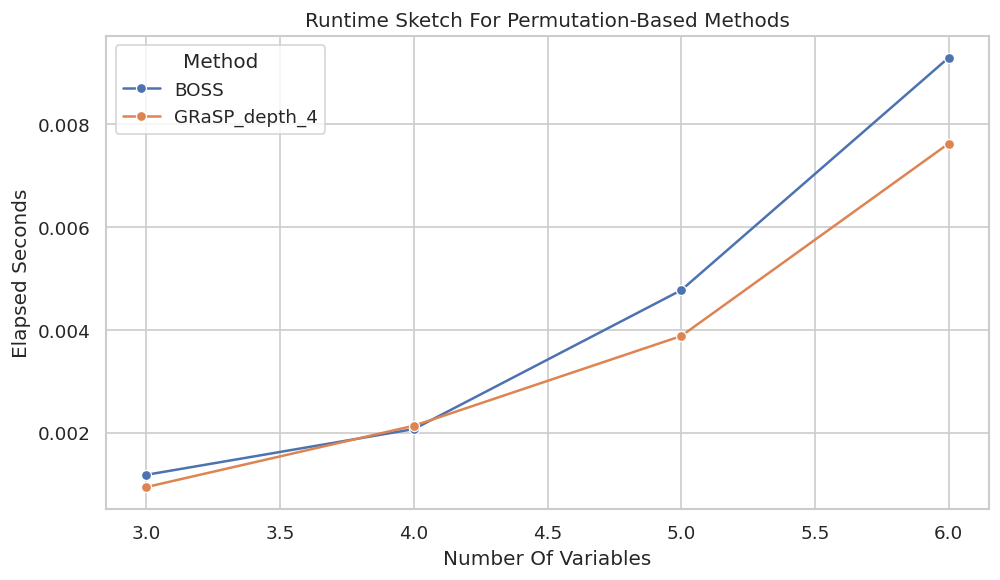

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(data=scaling_table, x="variable_count", y="elapsed_seconds", hue="method", marker="o", ax=ax)
ax.set_title("Runtime Sketch For Permutation-Based Methods")
ax.set_xlabel("Number Of Variables")
ax.set_ylabel("Elapsed Seconds")
ax.legend(title="Method")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_runtime_scaling_sketch.png", dpi=160, bbox_inches="tight")
plt.show()

For larger datasets, runtime should be measured and reported directly. Search depth, score type, parent-set complexity, and number of restarts can all change compute cost.




## Reporting and Takeaways

### Reporting Checklist

Permutation-based results should be reported as score-based search outputs with order-search settings. This checklist records the details that make BOSS and GRaSP analyses easier to audit.

| item | what_to_report | why_it_matters |
| --- | --- | --- |
| State the score function | BIC, BDeu, CV score, or another local score plus penalty settings. | The selected order and graph optimize this score, not a score-free causal criterion. |
| Report random seeds or restarts | Seeds used, number of starts, and whether graphs changed across starts. | Permutation search can depend on random traversal or initial order. |
| Document GRaSP depth | Depth setting and sensitivity results when GRaSP is used. | Depth changes the relaxation search and can change recovery. |
| Compare with another method | GES, PC, exact search on a small subproblem, or domain-constrained alternatives. | Agreement across search families is more reassuring than one graph alone. |
| Track runtime and graph size | Elapsed time, variable count, learned edge count, and any parent limits. | Order search can become expensive as graph size and score complexity grow. |
| Separate optimization from causality | What was optimized and which causal assumptions are still required. | A high-scoring permutation is not causal proof by itself. |


The checklist is deliberately practical. It keeps the final graph connected to the score, search settings, stability checks, and assumptions that produced it.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


This lesson now gives a complete permutation-based discovery workflow: order-search theory, fixed-order parent selection, BOSS and GRaSP runs, comparison with GES and exact search, seed stability, GRaSP depth sensitivity, sample-size sensitivity, runtime sketching, and reporting guidance.

The next tutorial can move to time-series causal discovery, where lag structure provides another source of direction information.